<a href="https://colab.research.google.com/github/renancotrin-alt/tech-challenge-fase-2-ibovespa/blob/V1_Ibovespa/notebooks/tech_challenge_fase_2_ibovespa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge Fase 2 - Previsao de Tendencia do IBOVESPA

Projeto desenvolvido para prever se o fechamento do IBOVESPA no proximo pregao sera maior ou menor que o fechamento do pregao atual.

A proposta segue o enunciado da atividade: usar dados historicos diarios do IBOVESPA, reservar os ultimos 30 pregoes disponiveis para teste e avaliar se o modelo atinge pelo menos 75% de acuracia.

## 1. Preparacao do ambiente

Este notebook foi organizado para rodar tanto no Google Colab quanto em ambiente local. No Colab, o repositorio publico sera clonado automaticamente antes da execucao.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/renancotrin-alt/tech-challenge-fase-2-ibovespa.git"
REPO_BRANCH = "V1_Ibovespa"
PROJECT_DIR = Path("tech-challenge-fase-2-ibovespa")

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    if not PROJECT_DIR.exists():
        subprocess.run(["git", "clone", "--branch", REPO_BRANCH, REPO_URL], check=True)
    os.chdir(PROJECT_DIR)
else:
    if Path.cwd().name == "notebooks":
        os.chdir("..")

print("Diretorio de trabalho:", Path.cwd())

Diretorio de trabalho: /content/tech-challenge-fase-2-ibovespa


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from src.data_prep import build_modeling_dataset, load_raw_data, save_processed_dataset, temporal_train_test_split
from src.modeling import FEATURE_COLUMNS, TARGET_COLUMN

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

## 2. Aquisicao e entendimento dos dados

A base foi obtida no Investing.com com periodicidade diaria. O arquivo original esta em `data/raw/dados_historicos_ibovespa.csv` e mantem o formato brasileiro de numeros, como `133.990` para representar 133.990 pontos.

In [3]:
raw_df = load_raw_data()
print("Linhas e colunas da base original:", raw_df.shape)
display(raw_df.head())
display(raw_df.tail())

Linhas e colunas da base original: (644, 7)


,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,31.07.2025,133.071,133.987,133.987,132.096,"9,20B","-0,69%"
1,30.07.2025,133.990,132.702,134.368,131.883,"8,66B","0,95%"
2,29.07.2025,132.726,132.130,133.346,132.130,"6,32B","0,45%"
3,28.07.2025,132.129,133.538,133.902,131.550,"6,63B","-1,04%"
4,25.07.2025,133.524,133.820,134.204,133.285,"5,56B","-0,21%"


,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
639,06.01.2023,108.964,107.642,109.433,107.642,"12,63M","1,23%"
640,05.01.2023,107.641,105.336,107.743,105.333,"15,51M","2,19%"
641,04.01.2023,105.334,104.167,105.627,103.915,"14,45M","1,12%"
642,03.01.2023,104.166,106.377,106.684,103.852,"14,47M","-2,08%"
643,02.01.2023,106.376,109.734,109.734,105.981,"8,13M","-3,06%"


## 3. Limpeza, target e engenharia de atributos

A preparacao transforma os campos numericos, ordena os pregoes cronologicamente e cria o target `alta_amanha`.

O target recebe valor `1` quando o fechamento do proximo pregao e maior que o fechamento atual; caso contrario, recebe `0`.

As features foram construidas apenas com informacoes conhecidas ate o dia da previsao, reduzindo risco de vazamento temporal.

In [4]:
df = build_modeling_dataset()
save_processed_dataset(df)

print("Base de modelagem:", df.shape)
print("Periodo:", df["data"].min().date(), "ate", df["data"].max().date())
print("Proporcao de altas no total:", f"{df[TARGET_COLUMN].mean():.2%}")
display(df.head())

Base de modelagem: (594, 51)
Periodo: 2023-03-14 ate 2025-07-30
Proporcao de altas no total: 50.67%


,data,fechamento,abertura,maxima,minima,volume,variacao_pct,volume_num,fechamento_amanha,alta_amanha,retorno_1d,retorno_2d,retorno_5d,retorno_10d,retorno_21d,retorno_lag_1,retorno_lag_2,retorno_lag_3,retorno_lag_5,media_movel_5,media_movel_10,media_movel_21,media_movel_50,distancia_mm5,distancia_mm21,distancia_mm50,amplitude_intradia,corpo_candle,volatilidade_5d,volatilidade_21d,volume_log,volume_media_5,volume_choque_5,maxima_5d,minima_5d,posicao_5d,maxima_21d,minima_21d,posicao_21d,alta_hoje,alta_lag_1,alta_lag_2,alta_lag_3,altas_5d,rsi_14,macd,macd_sinal,macd_hist,bollinger_pos,dia_semana,mes
0,2023-03-14,102932.0,103121.0,104153.0,102482.0,"13,13M",-0.0018,13130000.0,102675.0,0,-0.001833,-0.006620,-0.012434,-0.019060,-0.046997,-0.004796,-0.013829,-0.013788,-0.004508,104256.4,104178.7,106021.619048,108569.80,-0.012703,-0.029141,-0.051928,0.016305,-0.001833,0.014753,0.010451,16.390410,16.564778,-0.010526,106540.0,102932.0,0.000000,109941.0,102932.0,0.000000,0,0.0,0.0,0.0,1.0,33.084816,-1501.473545,-1336.093116,-165.380429,-0.655176,1,3
1,2023-03-15,102675.0,102930.0,103048.0,100692.0,"15,25M",-0.0025,15250000.0,103435.0,1,-0.002497,-0.004325,-0.036277,-0.016382,-0.049992,-0.001833,-0.004796,-0.013829,0.022182,103483.4,104007.7,105764.333333,108495.78,-0.007812,-0.029210,-0.053650,0.023398,-0.002477,0.005999,0.010430,16.540090,16.556430,-0.000987,105071.0,102675.0,0.000000,109941.0,102675.0,0.000000,0,0.0,0.0,0.0,0.0,29.991863,-1549.557746,-1378.786042,-170.771704,-0.643605,2,3
2,2023-03-16,103435.0,102683.0,103911.0,102455.0,"14,39M",0.0074,14390000.0,101982.0,0,0.007402,0.004887,-0.015570,0.001055,-0.049625,-0.002497,-0.001833,-0.004796,-0.013788,103156.2,104018.6,105507.142857,108481.16,0.002703,-0.019640,-0.046516,0.014211,0.007324,0.007587,0.010448,16.482044,16.499067,-0.001032,103618.0,102675.0,0.805938,109941.0,102675.0,0.104597,1,0.0,0.0,0.0,1.0,39.502443,-1508.944994,-1404.817832,-104.127161,-0.431343,3,3
3,2023-03-17,101982.0,103434.0,103434.0,101664.0,"17,56M",-0.0140,17560000.0,100923.0,0,-0.014047,-0.006749,-0.015789,-0.018139,-0.054400,0.007402,-0.002497,-0.001833,-0.013829,102829.0,103830.2,105227.761905,108414.12,-0.008237,-0.030845,-0.059329,0.017410,-0.014038,0.007664,0.010662,16.681134,16.494674,0.011304,103435.0,101982.0,0.000000,109941.0,101982.0,0.000000,0,1.0,0.0,0.0,1.0,35.227003,-1575.838764,-1439.022019,-136.816745,-0.701030,4,3
4,2023-03-20,100923.0,101982.0,102328.0,100679.0,"10,90M",-0.0104,10900000.0,100998.0,1,-0.010384,-0.024286,-0.021315,-0.036074,-0.079170,-0.014047,0.007402,-0.002497,-0.004796,102389.4,103452.5,104814.571429,108279.76,-0.014322,-0.037128,-0.067942,0.016379,-0.010384,0.008341,0.009862,16.204273,16.459590,-0.015512,103435.0,100923.0,0.000000,109941.0,100923.0,0.000000,0,0.0,1.0,0.0,1.0,34.462445,-1694.768768,-1490.171369,-204.597400,-0.903611,0,3


As principais familias de atributos criadas foram:

- retornos acumulados e defasados;
- medias moveis e distancia em relacao as medias;
- volatilidade recente;
- amplitude intradiaria e corpo do candle;
- posicao do fechamento dentro de janelas recentes;
- indicadores tecnicos simples, como RSI, MACD e posicao nas Bandas de Bollinger.

## 4. Analise exploratoria

Antes da modelagem, observamos a trajetoria do indice, a distribuicao dos retornos diarios e o equilibrio entre as classes do target.

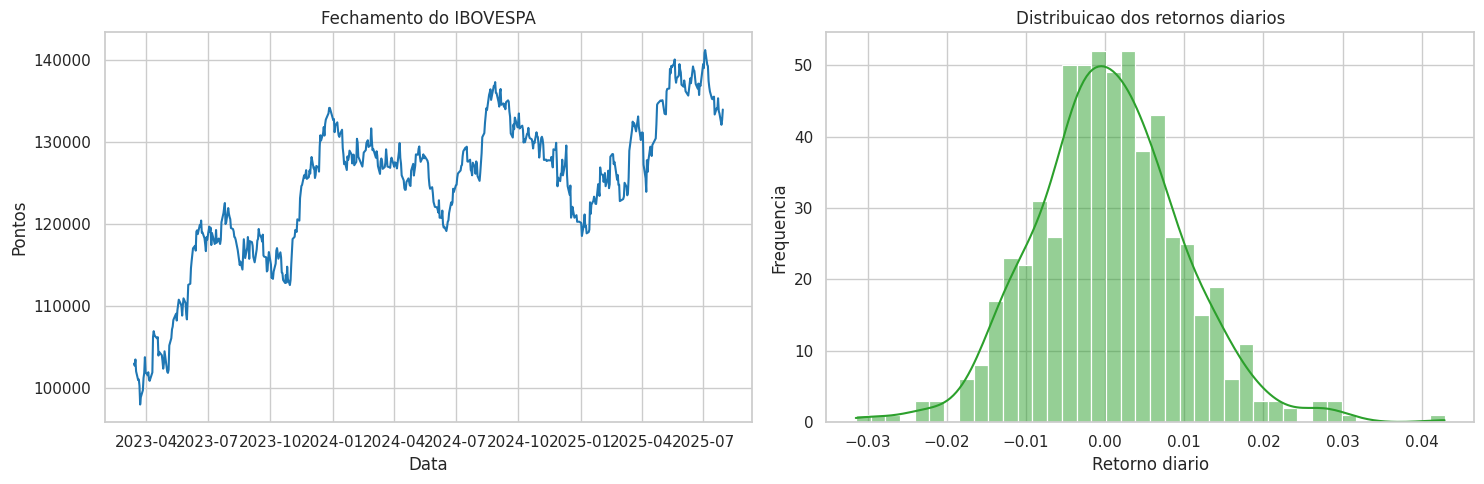

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=df, x="data", y="fechamento", ax=axes[0], color="#1f77b4")
axes[0].set_title("Fechamento do IBOVESPA")
axes[0].set_xlabel("Data")
axes[0].set_ylabel("Pontos")

sns.histplot(df["retorno_1d"], bins=40, kde=True, ax=axes[1], color="#2ca02c")
axes[1].set_title("Distribuicao dos retornos diarios")
axes[1].set_xlabel("Retorno diario")
axes[1].set_ylabel("Frequencia")

plt.tight_layout()
plt.show()

,classe,percentual
0,Alta,50.673401
1,Baixa/igual,49.326599


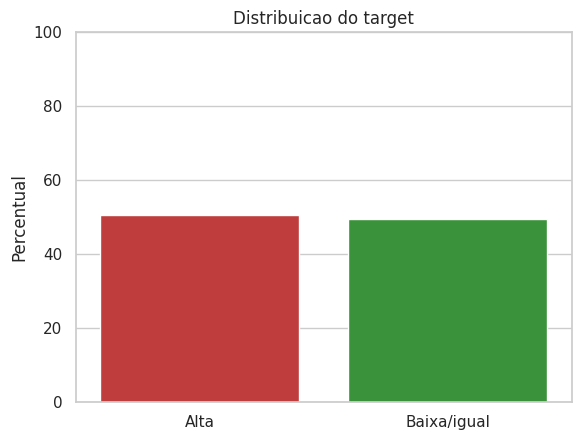

In [6]:
classe_df = (
    df[TARGET_COLUMN]
    .value_counts(normalize=True)
    .rename(index={0: "Baixa/igual", 1: "Alta"})
    .mul(100)
    .reset_index()
)
classe_df.columns = ["classe", "percentual"]

display(classe_df)
sns.barplot(data=classe_df, x="classe", y="percentual", hue="classe", palette=["#d62728", "#2ca02c"], legend=False)
plt.title("Distribuicao do target")
plt.ylabel("Percentual")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()

## 5. Separacao temporal entre treino e teste

Como se trata de serie temporal, a divisao nao pode ser aleatoria. O conjunto de teste foi formado pelos ultimos 30 pregoes disponiveis na base, simulando uma avaliacao em periodo futuro.

In [7]:
train_df, test_df = temporal_train_test_split(df, test_size=30)

print("Treino:", len(train_df), train_df["data"].min().date(), "ate", train_df["data"].max().date())
print("Teste:", len(test_df), test_df["data"].min().date(), "ate", test_df["data"].max().date())
print("Proporcao de altas no teste:", f"{test_df[TARGET_COLUMN].mean():.2%}")

Treino: 564 2023-03-14 ate 2025-06-17
Teste: 30 2025-06-18 ate 2025-07-30
Proporcao de altas no teste: 40.00%


## 6. Modelagem

Foram comparados dois baselines e quatro modelos de classificacao. O modelo final usa uma janela recente de 150 pregoes, pois o mercado financeiro muda de regime ao longo do tempo; dar peso excessivo a periodos antigos pode reduzir a capacidade de capturar o comportamento atual.

In [8]:
class MajorityClassBaseline:
    def fit(self, _x, y):
        self.majority_class_ = int(y.mode().iloc[0])
        return self

    def predict(self, x):
        return [self.majority_class_] * len(x)


class LastTrendBaseline:
    def fit(self, _x, y):
        self.last_class_ = int(y.iloc[-1])
        return self

    def predict(self, x):
        return [self.last_class_] * len(x)


model_specs = [
    ("Baseline - classe majoritaria", MajorityClassBaseline(), None),
    ("Baseline - ultima tendencia", LastTrendBaseline(), None),
    (
        "Regressao Logistica",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", C=0.1, random_state=42)),
        ]),
        None,
    ),
    (
        "Random Forest",
        RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=8, class_weight="balanced", random_state=42),
        None,
    ),
    (
        "Gradient Boosting",
        GradientBoostingClassifier(n_estimators=120, learning_rate=0.04, max_depth=2, min_samples_leaf=8, random_state=42),
        None,
    ),
    (
        "SVC - janela recente 150 pregoes",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(C=1.0, kernel="rbf", class_weight="balanced", random_state=42)),
        ]),
        150,
    ),
]

In [9]:
x_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET_COLUMN]

results = []
predictions = {}

for name, model, window_size in model_specs:
    model_train_df = train_df if window_size is None else train_df.tail(window_size)
    x_train = model_train_df[FEATURE_COLUMNS]
    y_train = model_train_df[TARGET_COLUMN]

    model.fit(x_train, y_train)
    y_pred = np.array(model.predict(x_test))
    predictions[name] = y_pred

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    results.append({
        "modelo": name,
        "janela_treino": len(model_train_df),
        "acuracia": accuracy_score(y_test, y_pred),
        "tn_baixa_correta": cm[0, 0],
        "fp_alta_errada": cm[0, 1],
        "fn_baixa_errada": cm[1, 0],
        "tp_alta_correta": cm[1, 1],
    })

results_df = pd.DataFrame(results).sort_values("acuracia", ascending=False)
results_df["acuracia"] = results_df["acuracia"].map(lambda value: f"{value:.2%}")
display(results_df)

,modelo,janela_treino,acuracia,tn_baixa_correta,fp_alta_errada,fn_baixa_errada,tp_alta_correta
5,SVC - janela recente 150 pregoes,150,76.67%,16,2,5,7
1,Baseline - ultima tendencia,564,60.00%,18,0,12,0
3,Random Forest,564,56.67%,13,5,8,4
2,Regressao Logistica,564,53.33%,12,6,8,4
4,Gradient Boosting,564,43.33%,11,7,10,2
0,Baseline - classe majoritaria,564,40.00%,0,18,0,12


## 7. Resultado final

O melhor desempenho no conjunto de teste foi obtido pelo SVC treinado com os 150 pregoes mais recentes do conjunto de treino.

Modelo final: SVC - janela recente 150 pregoes
Acuracia final: 76.67%

              precision    recall  f1-score   support

 Baixa/igual       0.76      0.89      0.82        18
        Alta       0.78      0.58      0.67        12

    accuracy                           0.77        30
   macro avg       0.77      0.74      0.74        30
weighted avg       0.77      0.77      0.76        30



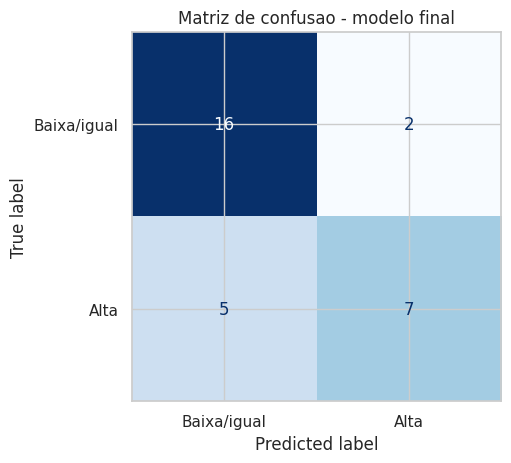

In [10]:
final_model_name = "SVC - janela recente 150 pregoes"
final_pred = predictions[final_model_name]

print("Modelo final:", final_model_name)
print("Acuracia final:", f"{accuracy_score(y_test, final_pred):.2%}")
print()
print(classification_report(y_test, final_pred, target_names=["Baixa/igual", "Alta"], zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    display_labels=["Baixa/igual", "Alta"],
    cmap="Blues",
    colorbar=False,
)
plt.title("Matriz de confusao - modelo final")
plt.show()

In [11]:
comparison_df = test_df[["data", "fechamento", "fechamento_amanha", TARGET_COLUMN]].copy()
comparison_df["previsao_alta"] = final_pred
comparison_df["acertou"] = comparison_df[TARGET_COLUMN] == comparison_df["previsao_alta"]
comparison_df["classe_real"] = comparison_df[TARGET_COLUMN].map({0: "Baixa/igual", 1: "Alta"})
comparison_df["classe_prevista"] = comparison_df["previsao_alta"].map({0: "Baixa/igual", 1: "Alta"})

display(comparison_df[["data", "fechamento", "fechamento_amanha", "classe_real", "classe_prevista", "acertou"]])

,data,fechamento,fechamento_amanha,classe_real,classe_prevista,acertou
564,2025-06-18,138717.0,137116.0,Baixa/igual,Baixa/igual,True
565,2025-06-20,137116.0,136551.0,Baixa/igual,Baixa/igual,True
566,2025-06-23,136551.0,137165.0,Alta,Alta,True
567,2025-06-24,137165.0,135767.0,Baixa/igual,Baixa/igual,True
568,2025-06-25,135767.0,137114.0,Alta,Baixa/igual,False
569,2025-06-26,137114.0,136866.0,Baixa/igual,Baixa/igual,True
570,2025-06-27,136866.0,138855.0,Alta,Baixa/igual,False
571,2025-06-30,138855.0,139549.0,Alta,Baixa/igual,False
572,2025-07-01,139549.0,139051.0,Baixa/igual,Baixa/igual,True
573,2025-07-02,139051.0,140928.0,Alta,Baixa/igual,False


## 8. Conclusao gerencial

O modelo final atingiu acuracia acima do minimo solicitado no teste temporal dos ultimos 30 pregoes. O resultado indica que os indicadores recentes do proprio IBOVESPA carregam algum sinal util para apoiar a leitura de tendencia do proximo pregao.

Mesmo assim, a previsao deve ser entendida como apoio analitico, nao como recomendacao automatica de compra ou venda. Mercados financeiros sao ruidosos e sensiveis a eventos externos; por isso, o modelo deve ser usado junto com outros indicadores e com revisao periodica.